# European Wind Droughts: Detecting & Tracking Low-Wind Spells in ERA5

A wind drought is a spell of days on which wind power output across a region stays well below its seasonal norm.
For a power system the duration of the spell matters, and so does its **footprint**: a lull confined to one country
can be covered by imports from its neighbours, while one that spans the North Sea, Germany and Poland at the same time
removes that option. Per-cell statistics answer the first question. Answering the second requires tracking each
spell as a single object through space and time, which is what marEx does.

This notebook builds a 45-year catalogue (1980-2024) of European wind droughts from ERA5:

| Step | marEx call | Choice here |
|---|---|---|
| Anomaly | `preprocess_data(method_anomaly="fixed_baseline")` | day-of-year climatology over the 1991-2020 normal, smoothed over 21 days |
| Extreme | `method_extreme="seasonal_percentile"`, `tail="lower"` | daily capacity factor below its day-of-year 10th percentile |
| Event | `regional_tracker(...)` | spells joined in space and time, with merges and splits followed |

The variable is the daily mean **capacity factor** of a generic wind turbine at 100 m hub height. The anomaly is taken
against a fixed reference period because there is no strong long-term trend in European near-surface wind that a moving
baseline would need to follow, and a fixed normal makes every year comparable. The same pipeline applied to sea surface
temperature with the upper tail produces marine heatwaves (see the [gridded tutorial](https://marex.readthedocs.io/en/latest/tutorials/index.html)).
Choosing the anomaly method and the threshold are covered in the [User Guide](https://marex.readthedocs.io/en/latest/guide/index.html), and the wider
energy and risk applications in [Applications](https://marex.readthedocs.io/en/latest/applications/index.html).

In [1]:
import os
from getpass import getuser
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import marEx
import marEx.helper as hpc

2026-10-09 10:57:33 - marEx - INFO - [PID:2522911] - MarEx logging configured - Level: INFO, Mode: normal


In [2]:
# Input: daily ERA5 wind over Europe, written by prepare_era5_wind.sh in this folder
data_path = Path(os.environ.get("MAREX_ERA5_WIND", "era5_wind_europe_daily.zarr"))

scratch_dir = Path("/scratch") / getuser()[0] / getuser()  # Lustre scratch
out_dir = scratch_dir / "marEx" / "examples" / "wind_drought"

reference_period = (1991, 2020)  # WMO climate normal used for the climatology
threshold_percentile = 10  # lower 10th percentile of the day-of-year distribution
min_days = 5  # a tracked spell lasting at least this long is counted as a wind drought in the catalogue

# One shared node: 4 workers x 4 threads x 3 GB
n_workers, threads_per_worker, memory_limit = 4, 4, "3GB"

SMOKE = False  # True runs on 1989-1996 only, to check the plumbing

In [3]:
out_dir.mkdir(parents=True, exist_ok=True)

# memory_limit is passed explicitly because on an HPC node Dask sizes workers from the whole node's memory,
# not from the job's allocation, and without it the workers can claim more than the job was granted.
client = hpc.start_local_cluster(
    n_workers=n_workers,
    threads_per_worker=threads_per_worker,
    memory_limit=memory_limit,
    scratch_dir=scratch_dir / "marEx" / "dask",
)

# Records wall time, peak memory, spill and worker restarts for each `monitor.stage(...)` block below
monitor = hpc.ResourceMonitor(client)

2026-10-09 10:57:40 - marEx.helper.cluster - INFO - [PID:2522911] - Starting local Dask cluster with 4 workers, 4 threads each


2026-10-09 10:57:40 - marEx.helper.dask_config - INFO - [PID:2522911] - Configuring Dask for HPC environment


2026-10-09 10:57:40 - marEx.helper.dask_config - INFO - [PID:2522911] - Dask temporary directory: /scratch/b/b382615/marEx/dask/tmpmgjdj868


2026-10-09 10:57:40 - marEx.helper.dask_config - INFO - [PID:2522911] - Dask configuration completed


2026-10-09 10:57:40 - marEx.helper.cluster - INFO - [PID:2522911] - System resources: 128 physical cores, 256 logical cores, 503.6GB total memory


...

2026-10-09 10:57:40 - marEx.helper.cluster - INFO - [PID:2522911] - Starting Local cluster startup


2026-10-09 10:57:43 - marEx.helper.cluster - INFO - [PID:2522911] - Completed Local cluster startup in 2.24s


Hostname: l40141
Forward Port: l40141:8787
Dashboard Link: localhost:8787/status
2026-10-09 10:57:43 - marEx.helper.cluster - INFO - [PID:2522911] - Local cluster started successfully - Dashboard: http://127.0.0.1:8787/status


2026-10-09 10:57:43 - marEx.helper.cluster - INFO - [PID:2522911] - After cluster startup - Memory Usage - RSS: 571.6MB, Virtual: 24695.9MB, Percent: 0.1%, Available: 501219.7MB


2026-10-09 10:57:43 - marEx.helper.resources - INFO - [PID:2522911] - Cluster: 4 workers, 16 threads, memory_limit per worker [3.0] GB (12 GB total)


## Input: Hub-Height Capacity Factor from ERA5

ERA5 provides hourly 10 m wind components on a 0.28° grid. `prepare_era5_wind.sh` converts them to daily fields over
12°W-35°E, 34°N-72°N in three steps, all done **hourly** before the daily mean is taken, because the power curve is
non-linear and a curve applied to a daily mean wind speed would misstate the output:

1. wind speed $U_{10} = \sqrt{u_{10}^2 + v_{10}^2}$,
2. extrapolation to hub height with a power law, $U_{100} = U_{10} \, (100/10)^{1/7}$,
3. a generic power curve: zero below a cut-in speed of 3 m/s, a cubic ramp to rated power at 12 m/s, rated output up to
   the cut-out at 25 m/s, and zero above it.

The result is an idealised capacity factor between 0 and 1 at every grid cell, onshore and offshore alike. It has no
turbine fleet, wake losses or curtailment in it, so it measures the wind resource rather than any real fleet's output.

In [4]:
ds = xr.open_zarr(data_path)
if SMOKE:
    ds = ds.sel(time=slice("1989-01-01", "1996-12-31"))
cf = ds.cf.chunk({"time": 30, "lat": -1, "lon": -1})  # spatially whole is right for a lat/lon grid
cf

<xarray.DataArray 'cf' (time: 16437, lat: 135, lon: 167)> Size: 1GB
dask.array<rechunk-merge, shape=(16437, 135, 167), dtype=float32, chunksize=(30, 135, 167), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB 34.15 34.43 34.71 34.99 ... 71.24 71.52 71.8
  * lon      (lon) float64 1kB -11.81 -11.53 -11.25 -10.97 ... 34.31 34.59 34.88
  * time     (time) datetime64[ns] 131kB 1980-01-01 1980-01-02 ... 2024-12-31
Attributes:
    CDI_grid_num_LPE:  320
    CDI_grid_type:     gaussian
    cell_methods:      time: mean
    long_name:         daily mean capacity factor, generic turbine, 100 m hub...
    units:             1

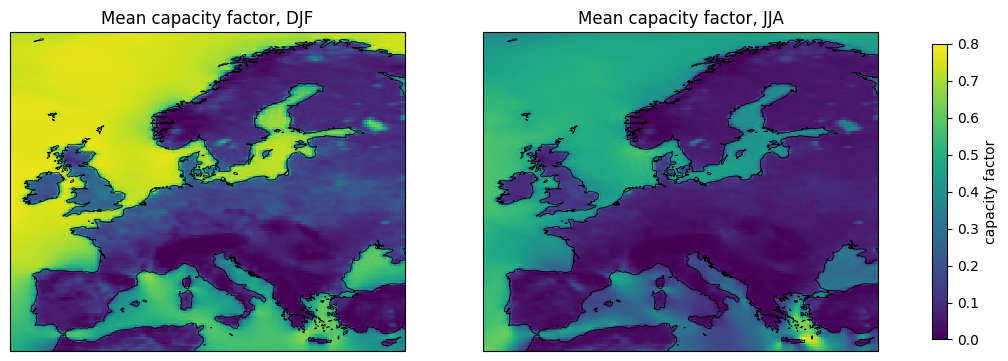

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, months, label in zip(axs, [[12, 1, 2], [6, 7, 8]], ["DJF", "JJA"]):
    clim = cf.sel(time=cf.time.dt.month.isin(months)).mean("time").compute()
    im = clim.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=0.8, add_colorbar=False)
    ax.coastlines(lw=0.6)
    ax.set_title(f"Mean capacity factor, {label}")
fig.colorbar(im, ax=axs, shrink=0.8, label="capacity factor")
plt.show()

## Detect: Lower-Tail Extremes of Capacity Factor

`fixed_baseline` builds a day-of-year climatology over the reference period and smooths it with a circular 21-day
moving average, so the anomaly removes the seasonal cycle without inheriting day-to-day noise from 30 years of samples.
`seasonal_percentile` with `tail="lower"` then sets a threshold for each day of year from the anomalies in an 11-day
window around it, pooled over a 5 × 5 neighbourhood of cells, and flags every cell-day at or below it. By construction
about 10 % of all cell-days are flagged. The interesting part is how those days cluster in space and time.

In [6]:
with monitor.stage("Detect: fixed baseline + seasonal 10th percentile (lower tail)"):
    extremes_ds = marEx.preprocess_data(
        cf,
        method_anomaly="fixed_baseline",
        reference_period=reference_period,
        smooth_days=21,  # circular moving average of the day-of-year climatology (days)
        method_extreme="seasonal_percentile",
        threshold_percentile=threshold_percentile,
        tail="lower",  # flag values at or below the threshold
        window_days=11,  # samples from an 11-day window around each day of year enter its percentile
        dimensions={"time": "time", "x": "lon", "y": "lat"},
        dask_chunks={"time": 30},
    )
    extremes_ds.to_zarr(out_dir / "wind_drought_extremes.zarr", mode="w")
extremes_ds = xr.open_zarr(out_dir / "wind_drought_extremes.zarr")
extremes_ds

2026-10-09 10:57:48 - marEx.pipeline - INFO - [PID:2522911] - Starting data preprocessing - Method: fixed_baseline -> seasonal_percentile


2026-10-09 10:57:48 - marEx.pipeline - INFO - [PID:2522911] - Parameters: percentile=10%, method_percentile=approximate


2026-10-09 10:57:48 - marEx.anomaly.api - INFO - [PID:2522911] - Computing anomalies - method: fixed_baseline


2026-10-09 10:57:49 - marEx.anomaly.api - INFO - [PID:2522911] - Starting Anomaly computation using fixed_baseline method


2026-10-09 10:57:51 - marEx.anomaly.api - INFO - [PID:2522911] - Completed Anomaly computation using fixed_baseline method in 2.21s


...

2026-10-09 11:01:10 - marEx.core.finalise - INFO - [PID:2522911] - Starting Dataset persistence and optimisation


2026-10-09 11:01:10 - marEx.core.finalise - INFO - [PID:2522911] - Completed Dataset persistence and optimisation in 0.02s


2026-10-09 11:01:22 - marEx.extremes.api - INFO - [PID:2522911] - Extreme identification completed - <xarray.DataArray 'extreme_events' ()> Size: 8B
array(31020596) extreme events identified


Detect: fixed baseline + seasonal 10th percentile (lower tail): 3.6 min, peak worker memory 6.2 GB of 12 GB, client 1.1 GB, spilled 3.4 GB, restarts 4


<xarray.Dataset> Size: 2GB
Dimensions:         (time: 16437, lat: 135, lon: 167, dayofyear: 366)
Coordinates:
  * dayofyear       (dayofyear) uint16 732B 1 2 3 4 5 6 ... 362 363 364 365 366
  * lat             (lat) float64 1kB 34.15 34.43 34.71 ... 71.24 71.52 71.8
  * lon             (lon) float64 1kB -11.81 -11.53 -11.25 ... 34.31 34.59 34.88
  * time            (time) datetime64[ns] 131kB 1980-01-01 ... 2024-12-31
Data variables:
    dat_anomaly     (time, lat, lon) float32 1GB dask.array<chunksize=(30, 135, 167), meta=np.ndarray>
    extreme_events  (time, lat, lon) bool 371MB dask.array<chunksize=(30, 135, 167), meta=np.ndarray>
    mask            (lat, lon) bool 23kB dask.array<chunksize=(135, 167), meta=np.ndarray>
    thresholds      (lat, lon, dayofyear) float32 33MB dask.array<chunksize=(135, 167, 30), meta=np.ndarray>
Attributes:
    max_anomaly:           0.8452442288398743
    method_anomaly:        fixed_baseline
    method_extreme:        seasonal_percentile
    method_percentile:     approximate
    precision:             0.0005634961525599162
    preprocessing_steps:   ['Daily climatology computed from 1991-2020', 'Cli...
    reference_period:      [1991, 2020]
    smooth_days:           21
    tail:                  lower
    threshold_percentile:  10
    window_days:           11
    window_spatial:        5

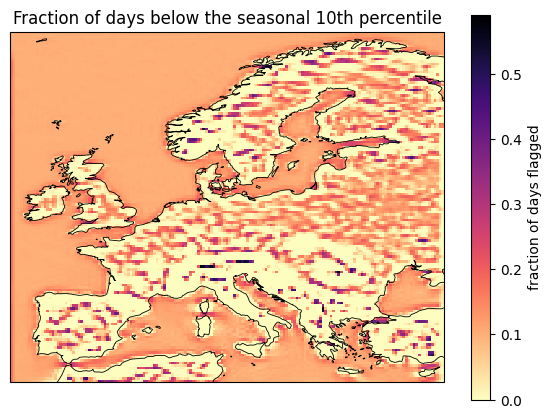

domain mean fraction flagged: 0.084


In [7]:
frac = extremes_ds.extreme_events.mean("time").compute()
fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={"projection": ccrs.PlateCarree()})
frac.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="magma_r", cbar_kwargs={"label": "fraction of days flagged"})
ax.coastlines(lw=0.6)
ax.set_title("Fraction of days below the seasonal 10th percentile")
plt.show()
print(f"domain mean fraction flagged: {float(frac.mean()):.3f}")

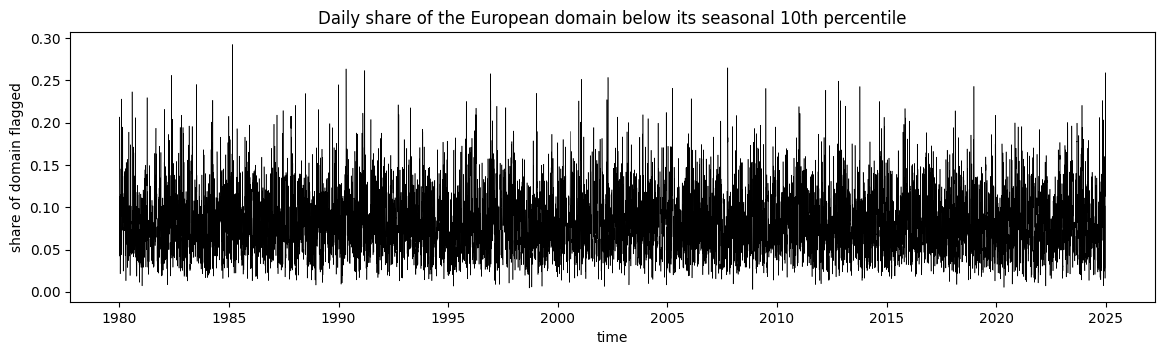

In [8]:
# Share of the domain in low-wind conditions on each day: the per-cell view, before tracking
area_w = np.cos(np.deg2rad(extremes_ds.lat))
share = extremes_ds.extreme_events.weighted(area_w).mean(["lat", "lon"]).compute()
fig, ax = plt.subplots(figsize=(14, 3.5))
share.plot(ax=ax, lw=0.4, color="k")
ax.set_ylabel("share of domain flagged")
ax.set_title("Daily share of the European domain below its seasonal 10th percentile")
plt.show()

## Track: Low-Wind Spells as Objects

The tracker treats the flagged cells as a binary field in (time, lat, lon) and identifies coherent objects:

- `R_fill=4` closes gaps of up to four cells inside a spell and removes speckle at its edge,
- `area_filter_absolute=1000` drops objects smaller than 1000 cells (roughly 600 000 km² at 50°N, about the area of
  France), which keeps synoptic-scale lulls and discards local ones,
- `T_fill=2` bridges a single day on which a spell drops below the area filter,
- `allow_merging=True` follows spells through mergers and splits, with an object keeping its ID only when it overlaps
  the previous day's object by at least half of the smaller one's area.

`regional_tracker` is the entry point for a domain that does not wrap around in longitude.

In [9]:
with monitor.stage("Track: regional tracker with merging"):
    events_ds = marEx.regional_tracker(
        extremes_ds.extreme_events,
        extremes_ds.mask,
        coordinate_units="degrees",
        R_fill=4,
        area_filter_absolute=1000,  # cells
        T_fill=2,
        allow_merging=True,
        overlap_threshold=0.5,
        nn_partitioning=True,
    ).run()
    # The tracker returns one day per chunk; larger chunks make far fewer files on disk
    events_ds.chunk({"time": 30}).to_zarr(out_dir / "wind_drought_events.zarr", mode="w")
events_ds = xr.open_zarr(out_dir / "wind_drought_events.zarr")
events_ds

2026-10-09 11:01:29 - marEx.track.tracker - INFO - [PID:2522911] - Initialising MarEx tracker


2026-10-09 11:01:29 - marEx.track.tracker - INFO - [PID:2522911] - Grid type: structured


2026-10-09 11:01:29 - marEx.track.tracker - INFO - [PID:2522911] - Parameters: R_fill=4, T_fill=2, area_filter_quartile=None, area_filter_absolute=1000, prefilter_min_cells=None


2026-10-09 11:01:29 - marEx.track.tracker - INFO - [PID:2522911] - No cell_areas provided for structured grid - using unit areas (cell counts)


2026-10-09 11:01:29 - marEx.track.tracker - INFO - [PID:2522911] - Starting complete tracking pipeline


...

2026-10-09 11:24:14 - marEx - INFO - [PID:2527371] - MarEx logging configured - Level: INFO, Mode: normal


2026-10-09 11:24:37 - marEx.track.tracker - ERROR - [PID:2522911] - Failed Small object filtering after 1363.64s: Attempted to run task 'finalize-hlgfinalizecompute-fae73e2023f34683a332373d6d720b85' on 51 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:38823. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.


2026-10-09 11:24:37 - marEx.track.tracker - ERROR - [PID:2522911] - Failed Data preprocessing after 1387.90s: Attempted to run task 'finalize-hlgfinalizecompute-fae73e2023f34683a332373d6d720b85' on 51 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:38823. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.


Track: regional tracker with merging: 23.1 min, peak worker memory 4.7 GB of 12 GB, client 1.1 GB, spilled 0.0 GB, restarts 49


KilledWorker: Attempted to run task 'finalize-hlgfinalizecompute-fae73e2023f34683a332373d6d720b85' on 51 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:38823. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

## An Event Catalogue

Each tracked spell becomes one row: its start and end, duration, the largest area it reached, and its total
**deficit**, the capacity-factor anomaly summed over every cell-day inside it (a negative number, in units of
capacity-factor × cell-days). Spells of at least `min_days` days are the wind droughts, and the table lists
the ten with the largest deficit. Areas are converted from cells to km² with the grid
spacing and the cosine of the event's centroid latitude.

In [ ]:
# Area per day is in cells (no grid_resolution was given), so convert it with the cell area at the event's centroid
R = 6371.0  # km
dlat = float(abs(extremes_ds.lat.diff("lat").mean()))
dlon = float(abs(extremes_ds.lon.diff("lon").mean()))
cent_lat = events_ds.centroid.isel(component=0)
area_km2 = events_ds.area * (R * np.deg2rad(dlat)) * (R * np.deg2rad(dlon)) * np.cos(np.deg2rad(cent_lat))
max_area = area_km2.max("time").compute()

# Deficit: anomaly summed over every cell-day of each event, accumulated one year at a time to bound memory
n = int(events_ds.ID.max()) + 1
deficit = np.zeros(n)
for year in np.unique(events_ds.time.dt.year):
    ids = events_ds.ID_field.sel(time=str(year)).values.ravel()
    vals = extremes_ds.dat_anomaly.sel(time=str(year)).values.ravel()
    inside = ids > 0
    deficit += np.bincount(ids[inside], weights=vals[inside], minlength=n)

cat = pd.DataFrame(
    {
        "start": pd.to_datetime(events_ds.time_start.values),
        "end": pd.to_datetime(events_ds.time_end.values),
    },
    index=events_ds.ID.values,
)
cat["days"] = (cat.end - cat.start).dt.days + 1
cat["max_area_Mkm2"] = max_area.sel(ID=cat.index).values / 1e6
cat["deficit"] = deficit[cat.index]
droughts = cat[cat.days >= min_days]
print(f"{len(cat)} tracked low-wind spells, of which {len(droughts)} last {min_days} days or more; longest {cat.days.max()} days")
droughts.sort_values("deficit").head(10).round(2)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
cat.days.plot.hist(ax=axs[0], bins=np.arange(0.5, cat.days.max() + 1.5), color="0.3")
axs[0].set_xlabel("duration (days)")
axs[0].set_yscale("log")
axs[0].set_title("Duration")

droughts.start.dt.month.value_counts().sort_index().reindex(range(1, 13), fill_value=0).plot.bar(ax=axs[1], color="0.3")
axs[1].set_xlabel("start month")
axs[1].set_title(f"Onset month, spells of {min_days}+ days")

axs[2].scatter(cat.days, cat.max_area_Mkm2, s=8, c=-cat.deficit, cmap="viridis")
axs[2].set_xlabel("duration (days)")
axs[2].set_ylabel("max area (million km²)")
axs[2].set_title("Size against duration (colour: |deficit|)")
plt.tight_layout()
plt.show()

## Anatomy of the Most Severe Spell

The event with the largest total deficit, shown every few days through its life. The outline is the tracked footprint
on that day, and the shading is the capacity-factor anomaly.

In [ ]:
worst = int(droughts.deficit.idxmin())
t0, t1 = cat.loc[worst, "start"], cat.loc[worst, "end"]
days = pd.date_range(t0, t1, periods=min(6, cat.loc[worst, "days"]))
fig, axs = plt.subplots(2, 3, figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, d in zip(axs.ravel(), days):
    a = extremes_ds.dat_anomaly.sel(time=d, method="nearest")
    a.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdBu", vmin=-0.4, vmax=0.4, add_colorbar=False)
    (events_ds.ID_field.sel(time=d, method="nearest") == worst).plot.contour(
        ax=ax, transform=ccrs.PlateCarree(), levels=[0.5], colors="k", linewidths=1.2
    )
    ax.coastlines(lw=0.5)
    ax.set_title(str(d.date()))
for ax in axs.ravel()[len(days) :]:
    ax.remove()
fig.suptitle(f"Event {worst}: {t0.date()} to {t1.date()}, {cat.loc[worst, 'days']} days")
plt.show()

In [ ]:
footprint = (events_ds.ID_field.sel(time=slice(t0, t1)) == worst).any("time").compute()
dom_cf = cf.weighted(area_w).mean(["lat", "lon"])
win = slice(t0 - pd.Timedelta(days=20), t1 + pd.Timedelta(days=20))
clim_dom = cf.sel(time=slice(f"{reference_period[0]}", f"{reference_period[1]}")).weighted(area_w).mean(["lat", "lon"])
clim_dom = clim_dom.groupby("time.dayofyear").mean().compute()
seg = dom_cf.sel(time=win).compute()

fig = plt.figure(figsize=(15, 4))
ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree())
footprint.plot(ax=ax0, transform=ccrs.PlateCarree(), cmap="Greys", add_colorbar=False)
ax0.coastlines(lw=0.5)
ax0.set_title("Cells touched by the event at any time")
ax1 = fig.add_subplot(1, 3, (2, 3))
seg.plot(ax=ax1, color="k", label="domain mean")
ax1.plot(seg.time, clim_dom.sel(dayofyear=seg.time.dt.dayofyear).values, color="0.6", ls="--", label="1991-2020 climatology")
ax1.axvspan(t0, t1, color="tab:blue", alpha=0.15, label="event")
ax1.set_ylabel("capacity factor")
ax1.legend()
ax1.set_title("Domain-mean capacity factor through the event")
plt.show()

## Events per Year

A tracked catalogue counts spells rather than cell-days, so a single long, continent-wide lull counts once. The counts
below are of spells lasting at least `min_days` days.

In [ ]:
per_year = droughts.groupby(droughts.start.dt.year).agg(events=("days", "size"), event_days=("days", "sum"))
fig, ax = plt.subplots(figsize=(14, 3.5))
per_year.events.plot.bar(ax=ax, color="0.3")
ax.set_xlabel("")
ax.set_ylabel("events starting")
ax.set_title(f"Wind droughts ({min_days}+ days) per year")
plt.show()

## Caveats

- The capacity factor comes from an idealised turbine and a 1/7 power-law profile applied everywhere. Real hub-height
  winds depend on stability and surface roughness, and real fleets are not spread uniformly over the domain. Weighting
  the field by installed capacity before detection would turn this into a fleet-specific analysis.
- ERA5's 10 m wind is a reanalysis product at about 30 km resolution. It represents synoptic-scale lulls well, and
  local orographic and coastal flows less well.
- The 10th percentile, the 1000-cell filter and the 5-day minimum define what counts as a wind drought. Both are parameters, and the catalogue's
  statistics should be read against them.

## Wall Time and Memory

One row per stage, measured while the notebook ran on the cluster configured at the top. Peak worker memory is the
summed process memory the workers report to the scheduler, which is the quantity Dask compares against `memory_limit`.
See the [Performance guide](https://marex.readthedocs.io/en/latest/guide/performance.html) for how to size a run.

In [ ]:
monitor.summary()

In [ ]:
client.close()